# 11 – Stacking Ensemble Classifier

This notebook develops and evaluates a Stacking Classifier for predicting waterborne disease risk levels.

The stacking ensemble combines selected individual classifiers developed during the previous modelling stages.

Base learners,
- Logistic Regression
- Random Forest
- XGBoost
- Multi-Layer Perceptron (MLP)

Logistic Regression is used as the meta-learner.

Stacking configurations are compared using cross-validation on the training dataset only. The held-out test dataset is reserved for the final unbiased evaluation of the selected stacking model.

In [1]:
# Import libraries required for the Stacking Classifier

from pathlib import Path
import time
import joblib

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.neural_network import MLPClassifier

from xgboost import XGBClassifier

# Import cross-validation tools for model selection
from sklearn.model_selection import StratifiedKFold, cross_val_score

# Import evaluation metrics for final test evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
# Define the project folders used by the Stacking Classifier

DATA_PATH = Path("../data/model_input")
MODEL_PATH = Path("../models")
RESULTS_PATH = MODEL_PATH / "results"

# Create the results folder if it does not already exist
RESULTS_PATH.mkdir(
    parents=True,
    exist_ok=True
)

print("Data folder:", DATA_PATH.resolve())
print("Model folder:", MODEL_PATH.resolve())
print("Results folder:", RESULTS_PATH.resolve())

Data folder: C:\Users\ASUS\Desktop\ICBT Assignments\1. New Batch Assignments\Final Project\Final_Project\data\model_input
Model folder: C:\Users\ASUS\Desktop\ICBT Assignments\1. New Batch Assignments\Final Project\Final_Project\models
Results folder: C:\Users\ASUS\Desktop\ICBT Assignments\1. New Batch Assignments\Final Project\Final_Project\models\results


In [3]:
# Load the prepared training and test datasets

X_train = pd.read_csv(
    DATA_PATH / "X_train.csv"
)

X_test = pd.read_csv(
    DATA_PATH / "X_test.csv"
)

y_train = pd.read_csv(
    DATA_PATH / "y_train.csv"
).squeeze("columns")

y_test = pd.read_csv(
    DATA_PATH / "y_test.csv"
).squeeze("columns")

# Display the dataset shapes
print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape :", y_test.shape)

X_train shape: (2400, 38)
X_test shape : (600, 38)
y_train shape: (2400,)
y_test shape : (600,)


In [4]:
# Check the training data before building the stacking model

print("Training Features:", X_train.shape)
print("Training Target:", y_train.shape)

# Check for missing values
print("\nMissing Values in X_train:")
print(X_train.isnull().sum().sum())

print("\nMissing Values in y_train:")
print(y_train.isnull().sum())

# Check the target class distribution
print("\nTraining Class Distribution:")
print(y_train.value_counts())

# Check the percentage distribution of each class
print("\nTraining Class Distribution (%):")
print(
    y_train.value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Training Features: (2400, 38)
Training Target: (2400,)

Missing Values in X_train:
0

Missing Values in y_train:
0

Training Class Distribution:
risk_level
Low       807
High      799
Medium    794
Name: count, dtype: int64

Training Class Distribution (%):
risk_level
Low       33.62
High      33.29
Medium    33.08
Name: proportion, dtype: float64


In [5]:
# Define the selected base learners using the final versions from the individual model notebooks

# Baseline Logistic Regression
logistic_base = Pipeline([
    (
        "scaler",
        StandardScaler()
    ),
    (
        "model",
        LogisticRegression(
            random_state=42,
            max_iter=1000
        )
    )
])


# Baseline Random Forest
random_forest_base = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)


# Tuned XGBoost
xgboost_base = XGBClassifier(
    colsample_bytree=1.0,
    learning_rate=0.2,
    max_depth=3,
    n_estimators=100,
    subsample=0.8,
    objective="multi:softprob",
    num_class=3,
    eval_metric="mlogloss",
    random_state=42,
    n_jobs=-1
)


# Tuned MLP Classifier
mlp_base = Pipeline([
    (
        "scaler",
        StandardScaler()
    ),
    (
        "model",
        MLPClassifier(
            hidden_layer_sizes=(128, 64),
            activation="tanh",
            alpha=0.0001,
            learning_rate_init=0.001,
            solver="adam",
            max_iter=300,
            early_stopping=True,
            validation_fraction=0.2,
            random_state=42
        )
    )
])


# Combine the four selected models as stacking base learners
estimators = [
    ("logistic", logistic_base),
    ("random_forest", random_forest_base),
    ("xgboost", xgboost_base),
    ("mlp", mlp_base)
]


print("Selected stacking base learners:")
print("- Baseline Logistic Regression")
print("- Baseline Random Forest")
print("- Tuned XGBoost")
print("- Tuned MLP")

Selected stacking base learners:
- Baseline Logistic Regression
- Baseline Random Forest
- Tuned XGBoost
- Tuned MLP


In [6]:
# Define 5-fold Stratified Cross-Validation for stacking model selection

stacking_cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

print("Cross-validation strategy created successfully.")
print("Number of folds: 5")
print("Model selection will use X_train and y_train only.")

Cross-validation strategy created successfully.
Number of folds: 5
Model selection will use X_train and y_train only.


In [7]:
# Define the baseline Stacking Classifier

baseline_meta_model = LogisticRegression(
    C=1.0,
    penalty="l2",
    solver="lbfgs",
    max_iter=1000,
    random_state=42
)

baseline_stack = StackingClassifier(
    estimators=estimators,
    final_estimator=baseline_meta_model,
    cv=stacking_cv,
    stack_method="predict_proba",
    passthrough=False,
    n_jobs=-1
)

print("Baseline Stacking Classifier created successfully.")

Baseline Stacking Classifier created successfully.


In [8]:
# Evaluate the baseline Stacking Classifier using training-set cross-validation only

baseline_cv_scores = cross_val_score(
    baseline_stack,
    X_train,
    y_train,
    cv=stacking_cv,
    scoring="f1_weighted",
    n_jobs=-1
)

baseline_cv_mean = baseline_cv_scores.mean()
baseline_cv_std = baseline_cv_scores.std()

print("Baseline Stacking Cross-Validation Results")
print("=" * 55)

print("Fold F1-Scores:")
print(
    baseline_cv_scores.round(4)
)

print(
    f"\nMean Weighted F1-Score: {baseline_cv_mean:.4f}"
)

print(
    f"Standard Deviation     : {baseline_cv_std:.4f}"
)

Baseline Stacking Cross-Validation Results
Fold F1-Scores:
[0.8552 0.9004 0.8483 0.8751 0.8692]

Mean Weighted F1-Score: 0.8696
Standard Deviation     : 0.0181


In [9]:
# Define stacking configurations for cross-validation tuning

stacking_candidates = []

for passthrough_value in [False, True]:

    for meta_c in [0.1, 1.0, 10.0]:

        # Create the Logistic Regression meta-learner
        meta_model = LogisticRegression(
            C=meta_c,
            penalty="l2",
            solver="lbfgs",
            max_iter=1000,
            random_state=42
        )

        # Create one stacking configuration
        candidate_model = StackingClassifier(
            estimators=estimators,
            final_estimator=meta_model,
            cv=stacking_cv,
            stack_method="predict_proba",
            passthrough=passthrough_value,
            n_jobs=-1
        )

        stacking_candidates.append({
            "Passthrough": passthrough_value,
            "Meta C": meta_c,
            "Model": candidate_model
        })

print(
    f"{len(stacking_candidates)} stacking configurations created."
)

6 stacking configurations created.


In [10]:
# Evaluate all stacking configurations using 5-fold cross-validation on the training data

tuning_results = []

for candidate in stacking_candidates:

    cv_scores = cross_val_score(
        candidate["Model"],
        X_train,
        y_train,
        cv=stacking_cv,
        scoring="f1_weighted",
        n_jobs=-1
    )

    tuning_results.append({
        "Passthrough": candidate["Passthrough"],
        "Meta C": candidate["Meta C"],
        "Mean CV F1-Score": cv_scores.mean(),
        "CV Standard Deviation": cv_scores.std()
    })


# Convert the tuning results into a comparison table
tuning_results_df = pd.DataFrame(
    tuning_results
)


# Rank configurations by the highest mean cross-validation F1-score
tuning_results_df = tuning_results_df.sort_values(
    by="Mean CV F1-Score",
    ascending=False
).reset_index(drop=True)


# Round the results for easier reading
tuning_results_df = tuning_results_df.round(4)

tuning_results_df

,Passthrough,Meta C,Mean CV F1-Score,CV Standard Deviation
0,False,0.1,0.8711,0.0184
1,False,10.0,0.8697,0.0182
2,False,1.0,0.8696,0.0181
3,True,10.0,0.8672,0.0202
4,True,0.1,0.8657,0.0184
5,True,1.0,0.8654,0.0185


In [11]:
# Select the best stacking configuration using cross-validation results

best_passthrough = tuning_results_df.loc[
    0,
    "Passthrough"
]

best_meta_c = tuning_results_df.loc[
    0,
    "Meta C"
]

best_cv_f1 = tuning_results_df.loc[
    0,
    "Mean CV F1-Score"
]

best_cv_std = tuning_results_df.loc[
    0,
    "CV Standard Deviation"
]

print("Best Stacking Configuration")
print("=" * 50)

print("Passthrough:", best_passthrough)
print("Meta C:", best_meta_c)
print("CV F1-Score:", best_cv_f1)
print("CV Standard Deviation:", best_cv_std)

Best Stacking Configuration
Passthrough: False
Meta C: 0.1
CV F1-Score: 0.8711
CV Standard Deviation: 0.0184


In [12]:
# Build the final Stacking Classifier using the best cross-validation configuration

final_meta_model = LogisticRegression(
    C=best_meta_c,
    penalty="l2",
    solver="lbfgs",
    max_iter=1000,
    random_state=42
)

final_stack = StackingClassifier(
    estimators=estimators,
    final_estimator=final_meta_model,
    cv=stacking_cv,
    stack_method="predict_proba",
    passthrough=best_passthrough,
    n_jobs=-1
)

print("Final Stacking Classifier created successfully.")
print("Selected Meta C:", best_meta_c)
print("Selected Passthrough:", best_passthrough)

Final Stacking Classifier created successfully.
Selected Meta C: 0.1
Selected Passthrough: False


In [13]:
# Train the final Stacking Classifier on the full training dataset

start_time = time.time()

final_stack.fit(
    X_train,
    y_train
)

training_time = time.time() - start_time

print("Final Stacking Classifier trained successfully.")
print(f"Training Time: {training_time:.4f} seconds")

Final Stacking Classifier trained successfully.
Training Time: 1.5136 seconds


c:\Users\ASUS\Desktop\ICBT Assignments\1. New Batch Assignments\Final Project\Final_Project\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


In [14]:
# Evaluate the final Stacking Classifier on the held-out test dataset

train_predictions = final_stack.predict(
    X_train
)

test_predictions = final_stack.predict(
    X_test
)

train_accuracy = accuracy_score(
    y_train,
    train_predictions
)

test_accuracy = accuracy_score(
    y_test,
    test_predictions
)

precision = precision_score(
    y_test,
    test_predictions,
    average="weighted",
    zero_division=0
)

recall = recall_score(
    y_test,
    test_predictions,
    average="weighted",
    zero_division=0
)

f1 = f1_score(
    y_test,
    test_predictions,
    average="weighted",
    zero_division=0
)

generalisation_gap = (
    train_accuracy
    - test_accuracy
)

print("=" * 60)
print("Final Stacking Classifier Performance")
print("=" * 60)

print(f"Training Accuracy : {train_accuracy:.4f}")
print(f"Testing Accuracy  : {test_accuracy:.4f}")
print(f"Precision         : {precision:.4f}")
print(f"Recall            : {recall:.4f}")
print(f"F1-Score          : {f1:.4f}")
print(f"Training Time (s) : {training_time:.4f}")
print(f"Generalisation Gap: {generalisation_gap:.4f}")

Final Stacking Classifier Performance
Training Accuracy : 0.9617
Testing Accuracy  : 0.8517
Precision         : 0.8525
Recall            : 0.8517
F1-Score          : 0.8520
Training Time (s) : 1.5136
Generalisation Gap: 0.1100


In [15]:
# Display the classification report for the final Stacking Classifier

print("Final Stacking Classifier - Classification Report")
print("=" * 60)

print(
    classification_report(
        y_test,
        test_predictions,
        zero_division=0
    )
)

Final Stacking Classifier - Classification Report
              precision    recall  f1-score   support

        High       0.87      0.88      0.88       200
         Low       0.91      0.89      0.90       202
      Medium       0.77      0.78      0.78       198

    accuracy                           0.85       600
   macro avg       0.85      0.85      0.85       600
weighted avg       0.85      0.85      0.85       600



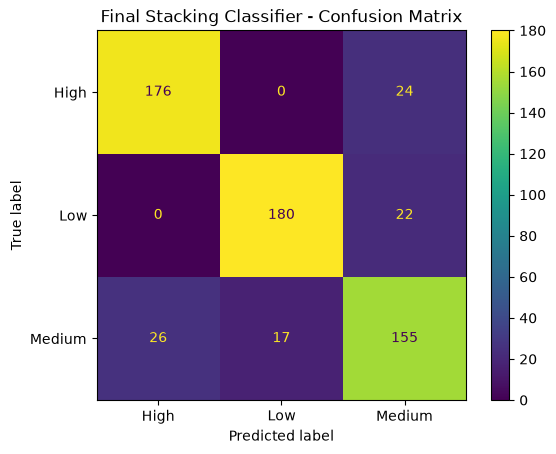

In [16]:
# Display the confusion matrix for the final Stacking Classifier

cm = confusion_matrix(
    y_test,
    test_predictions
)

display = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=final_stack.classes_
)

display.plot()

plt.title(
    "Final Stacking Classifier - Confusion Matrix"
)

plt.show()

In [17]:
# Save both the baseline and tuned Stacking Classifier models

# Train the baseline stacking model on the full training dataset
baseline_stack.fit(
    X_train,
    y_train
)

# Save the baseline stacking model
joblib.dump(
    baseline_stack,
    MODEL_PATH / "stacking_classifier_baseline.pkl"
)

# Save the tuned stacking model
joblib.dump(
    final_stack,
    MODEL_PATH / "stacking_classifier_tuned.pkl"
)

print("Baseline Stacking model saved successfully.")
print("Tuned Stacking model saved successfully.")

Baseline Stacking model saved successfully.
Tuned Stacking model saved successfully.


c:\Users\ASUS\Desktop\ICBT Assignments\1. New Batch Assignments\Final Project\Final_Project\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


In [18]:
# Save the final tuned Stacking Classifier performance results

stacking_results = pd.DataFrame({
    "Model": ["Stacking Classifier"],
    "Version": ["Tuned"],
    "Training Accuracy": [train_accuracy],
    "Testing Accuracy": [test_accuracy],
    "Precision": [precision],
    "Recall": [recall],
    "F1-Score": [f1],
    "Training Time (s)": [training_time],
    "Generalisation Gap": [generalisation_gap],
    "CV F1-Score": [best_cv_f1]
})

# Round numerical values for consistent result storage
stacking_results = stacking_results.round(4)

# Save the results as a CSV file
stacking_results.to_csv(
    RESULTS_PATH / "stacking_results.csv",
    index=False
)

print("Stacking results saved successfully.")
print(
    "Saved to:",
    (RESULTS_PATH / "stacking_results.csv").resolve()
)

stacking_results

Stacking results saved successfully.
Saved to: C:\Users\ASUS\Desktop\ICBT Assignments\1. New Batch Assignments\Final Project\Final_Project\models\results\stacking_results.csv


,Model,Version,Training Accuracy,Testing Accuracy,Precision,Recall,F1-Score,Training Time (s),Generalisation Gap,CV F1-Score
0,Stacking Classifier,Tuned,0.9617,0.8517,0.8525,0.8517,0.852,1.5136,0.11,0.8711


## Conclusion

A Stacking Classifier was developed using Logistic Regression, Random Forest, XGBoost and MLP as base learners with Logistic Regression used as the meta-learner.

To avoid test-set leakage the stacking configuration was selected using 5-fold stratified cross-validation on the training dataset only. The best configuration used `C = 0.1` with `passthrough = False`, achieving a cross-validation F1-score of 0.8711.

After the configuration was fixed the model was trained on the full training dataset and evaluated once on the held-out test dataset. The final Stacking Classifier achieved a testing accuracy of 85.17% and an F1-score of 85.20%, with a generalisation gap of 11.00%.

The final stacking model and its evaluation results were saved for use in the overall model comparison.